# Exercise 1 - Sentiment Construction

This notebook constructs sentiment measures from the cleaned forward-looking sentence dataset created in the preprocessing stage.

This notebook covers:
1. Loading cleaned Exercise 1 inputs
2. Lexicon-based sentence scoring
3. Aggregation to company-call level
4. Aggregation to sector-month sentiment indicators
5. Export of scored outputs

In [5]:
# Setup

from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 200)

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().resolve().parent
else:
    PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: D:\Desk\F550_final_peoject


## 1. Import local sentiment functions
Load the functions used for lexicon-based sentence scoring and aggregation.

In [6]:
# import local functions

from src_ex1.ex1_sentiment import (
    load_word_list,
    apply_lexicon_scoring,
    aggregate_to_call_level,
    aggregate_to_sector_month,
)

## 2. Load cleaned sentence-level input
Load the forward-looking sentence dataset produced in the preprocessing notebook.

In [7]:
# load cleaned sentence sample

sentence_sample_path = PROCESSED_DIR / "ex1_forward_looking_sentences_2024.parquet"

sent_all = pd.read_parquet(sentence_sample_path)
print(sent_all.shape)
sent_all.head()

(4526, 11)


,symbol,company_name,quarter,year,date,segment_id,speaker,sentence_id,sentence,sector,sub_industry
0,AAPL,Apple Inc.,4,2024,2024-10-31 17:00:00,13,Tim Cook,1,"On Apple Intelligence, we believe it's a compelling upgrade reason.",Information Technology,"Technology Hardware, Storage & Peripherals"
1,AAPL,Apple Inc.,4,2024,2024-10-31 17:00:00,13,Tim Cook,7,"And so, if you look at how we've done this year, we did that very quickly on the 16, on the 16 Pro family, the Pro and the Pro Max, we've been constrained in October, but we believe that soon we'l...",Information Technology,"Technology Hardware, Storage & Peripherals"
2,AAPL,Apple Inc.,4,2024,2024-10-31 17:00:00,39,David Vogt,4,"So, should we see something different, let's say, in the December quarter, the March quarter, the June quarter, et cetera, relative to history, given the timing of the rollout and where customers ...",Information Technology,"Technology Hardware, Storage & Peripherals"
3,AAPL,Apple Inc.,4,2024,2024-10-31 17:00:00,60,Tim Cook,3,"And what that does to Services, I'll not forecast, but I would say that from an ecosystem point of view, I think it will be great for the user and the user experience.",Information Technology,"Technology Hardware, Storage & Peripherals"
4,AAPL,Apple Inc.,3,2024,2024-08-01 17:00:00,41,Luca Maestri,0,"And from a gross margin standpoint, as you know, we don't provide any color past the current quarter, and we just provided guidance for the quarter 45.5% to 46.5%.",Information Technology,"Technology Hardware, Storage & Peripherals"


## 3. Build the LM lexicon
Load the Loughran-McDonald master dictionary and construct positive and negative word sets for lexicon-based sentiment scoring.

In [8]:
# load LM master dictionary

lexicon_dir = RAW_DIR / "lexicons"
lm_path = lexicon_dir / "lm_master_dictionary.csv"

lm = pd.read_csv(lm_path)

print("LM dictionary shape:", lm.shape)
lm.head()

LM dictionary shape: (86553, 17)


,Word,Seq_num,Word Count,Word Proportion,Average Proportion,Std Dev,Doc Count,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Complexity,Syllables,Source
0,AARDVARK,1,755,2.955070e-08,1.945421e-08,4.078069e-06,140,0,0,0,0,0,0,0,0,2,12of12inf
1,AARDVARKS,2,3,1.174200e-10,8.060019e-12,8.919011e-09,1,0,0,0,0,0,0,0,0,2,12of12inf
2,ABACI,3,9,3.522600e-10,1.089343e-10,5.105359e-08,7,0,0,0,0,0,0,0,0,3,12of12inf
3,ABACK,4,29,1.135060e-09,6.197922e-10,1.539279e-07,28,0,0,0,0,0,0,0,0,2,12of12inf
4,ABACUS,5,9620,3.765268e-07,3.825261e-07,3.421836e-05,1295,0,0,0,0,0,0,0,0,3,12of12inf


In [9]:
# build positive and negative word sets

# Standardize word format
lm["Word"] = lm["Word"].astype(str).str.lower().str.strip()

# Construct LM positive and negative word sets
positive_words = set(
    lm.loc[lm["Positive"] > 0, "Word"]
    .dropna()
    .tolist()
)

negative_words = set(
    lm.loc[lm["Negative"] > 0, "Word"]
    .dropna()
    .tolist()
)

print("Number of LM positive words:", len(positive_words))
print("Number of LM negative words:", len(negative_words))

Number of LM positive words: 347
Number of LM negative words: 2345


## 4. Apply lexicon-based sentence scoring
Score each forward-looking sentence using the Loughran-McDonald positive and negative word lists.

The sentence-level lexicon score is defined as:

$$
\text{lexicon\_score} = \frac{\text{pos\_count} - \text{neg\_count}}{\text{pos\_count} + \text{neg\_count} + 1}
$$

This definition produces a continuous score while keeping the measure simple and interpretable.

In [10]:
# apply lexicon scoring

sent_lex = apply_lexicon_scoring(
    df=sent_all,
    sentence_col="sentence",
    positive_words=positive_words,
    negative_words=negative_words,
)

print("Sentence-level scored table shape:", sent_lex.shape)

sent_lex[
    [
        "symbol",
        "company_name",
        "sector",
        "date",
        "speaker",
        "sentence",
        "pos_count",
        "neg_count",
        "lexicon_score",
    ]
].head(20)

Sentence-level scored table shape: (4526, 15)


,symbol,company_name,sector,date,speaker,sentence,pos_count,neg_count,lexicon_score
0,AAPL,Apple Inc.,Information Technology,2024-10-31 17:00:00,Tim Cook,"On Apple Intelligence, we believe it's a compelling upgrade reason.",0,0,0.0
1,AAPL,Apple Inc.,Information Technology,2024-10-31 17:00:00,Tim Cook,"And so, if you look at how we've done this year, we did that very quickly on the 16, on the 16 Pro family, the Pro and the Pro Max, we've been constrained in October, but we believe that soon we'l...",0,0,0.0
2,AAPL,Apple Inc.,Information Technology,2024-10-31 17:00:00,David Vogt,"So, should we see something different, let's say, in the December quarter, the March quarter, the June quarter, et cetera, relative to history, given the timing of the rollout and where customers ...",1,0,0.5
3,AAPL,Apple Inc.,Information Technology,2024-10-31 17:00:00,Tim Cook,"And what that does to Services, I'll not forecast, but I would say that from an ecosystem point of view, I think it will be great for the user and the user experience.",0,0,0.0
4,AAPL,Apple Inc.,Information Technology,2024-08-01 17:00:00,Luca Maestri,"And from a gross margin standpoint, as you know, we don't provide any color past the current quarter, and we just provided guidance for the quarter 45.5% to 46.5%.",0,0,0.0
5,AAPL,Apple Inc.,Information Technology,2024-08-01 17:00:00,David Vogt,"But if I kind of take your comments at face value, I guess what I'm trying to think about is for the next quarter, it sounds like with Services being relatively strong and FX easing a little bit.",1,1,0.0
6,AAPL,Apple Inc.,Information Technology,2024-08-01 17:00:00,David Vogt,"And so I'm just trying to get a sense for, what are the puts and takes in that sort of outlook particularly as you have Apple Intelligence hopefully stoking the fire for demand going forward?",0,0,0.0
7,AAPL,Apple Inc.,Information Technology,2024-08-01 17:00:00,Tim Cook,"Our objective that we said in June is to roll out US English starting in the fall and that is to users, and then proceed with more functionality, more features, if you will, and more languages and...",0,0,0.0
8,AAPL,Apple Inc.,Information Technology,2024-05-02 17:00:00,Mike Ng,"And I wanted to ask about, as Apple leans more into AI and Generative AI, should we expect any changes to the historical CapEx cadence that we've seen in the last few years of about $10 billion to...",0,0,0.0
9,AAPL,Apple Inc.,Information Technology,2024-05-02 17:00:00,Luca Maestri,It's a model that has worked well for us historically and we plan to continue along the same lines going forward.,0,0,0.0


In [11]:
# summary statistics for sentence-level scores

sent_lex["lexicon_score"].describe()

count    4526.000000
mean        0.120472
std         0.299162
min        -0.750000
25%         0.000000
50%         0.000000
75%         0.500000
max         0.875000
Name: lexicon_score, dtype: float64

In [12]:
# show share of non-zero sentence scores

nonzero_share = (sent_lex["lexicon_score"] != 0).mean()

print("Share of non-zero sentence scores:", round(nonzero_share, 4))

Share of non-zero sentence scores: 0.3551


## 5. Aggregate sentiment to company-call level
Aggregate sentence-level lexicon scores to the company-call level by averaging across all forward-looking sentences within the same transcript date.

In [13]:
# aggregate to call level

call_lex = aggregate_to_call_level(sent_lex)

print("Call-level sentiment table shape:", call_lex.shape)
call_lex.head(20)

Call-level sentiment table shape: (419, 8)


,symbol,company_name,sector,date,call_lexicon_score,n_sentences,total_pos_words,total_neg_words
0,AAPL,Apple Inc.,Information Technology,2024-02-01 17:00:00,-0.250000,2,0,1
1,AAPL,Apple Inc.,Information Technology,2024-05-02 17:00:00,0.250000,12,6,0
2,AAPL,Apple Inc.,Information Technology,2024-08-01 17:00:00,0.000000,4,1,1
3,AAPL,Apple Inc.,Information Technology,2024-10-31 17:00:00,0.125000,4,1,0
4,ACN,Accenture plc,Information Technology,2024-03-21 08:00:00,0.125000,14,5,0
5,ACN,Accenture plc,Information Technology,2024-06-20 08:00:00,0.083333,6,1,0
6,ACN,Accenture plc,Information Technology,2024-09-26 08:00:00,0.027778,18,2,1
7,ADBE,Adobe Inc.,Information Technology,2024-03-14 17:00:00,0.145833,16,7,1
8,ADBE,Adobe Inc.,Information Technology,2024-06-13 17:00:00,0.000000,2,0,0
9,ADBE,Adobe Inc.,Information Technology,2024-09-12 17:00:00,0.416667,12,12,0


In [14]:
# quick call-level summary

call_lex["call_lexicon_score"].describe()

count    419.000000
mean       0.118829
std        0.133890
min       -0.500000
25%        0.029514
50%        0.109375
75%        0.191071
max        0.625000
Name: call_lexicon_score, dtype: float64

## 6. Aggregate sentiment to sector-month level
Construct the sector-level sentiment indicator by averaging company-call sentiment scores within each sector-month.

In [15]:
# aggregate to sector-month level

sector_month_lex = aggregate_to_sector_month(call_lex)

print("Sector-month sentiment table shape:", sector_month_lex.shape)
sector_month_lex.head(20)

Sector-month sentiment table shape: (24, 5)


,sector,month,sector_lexicon_score,n_calls,n_firms
0,Industrials,2024-01,0.203846,3,3
1,Industrials,2024-02,0.158523,8,8
2,Industrials,2024-03,0.166171,2,2
3,Industrials,2024-04,0.072449,48,48
4,Industrials,2024-05,0.093937,25,25
5,Industrials,2024-06,0.238194,2,2
6,Industrials,2024-07,0.141289,51,51
7,Industrials,2024-08,0.143892,20,20
8,Industrials,2024-09,0.000000,1,1
9,Industrials,2024-10,0.129265,56,56


In [16]:
# inspect the sector-month table

sector_month_lex.sort_values(["month", "sector"]).head(30)

,sector,month,sector_lexicon_score,n_calls,n_firms
0,Industrials,2024-01,0.203846,3,3
12,Information Technology,2024-01,0.176838,12,12
1,Industrials,2024-02,0.158523,8,8
13,Information Technology,2024-02,0.109842,18,18
2,Industrials,2024-03,0.166171,2,2
14,Information Technology,2024-03,0.130456,6,6
3,Industrials,2024-04,0.072449,48,48
15,Information Technology,2024-04,0.092097,26,26
4,Industrials,2024-05,0.093937,25,25
16,Information Technology,2024-05,0.097433,25,25


## 7. Save lexicon-based outputs
Save the sentence-level, call-level, and sector-month lexicon sentiment tables for later analysis and visualization.

In [17]:
sent_all["date"] = pd.to_datetime(sent_all["date"], errors="coerce")
sent_all["date"].dt.year.value_counts().sort_index()

date
2024    4526
Name: count, dtype: int64

In [18]:
# save outputs

sent_lex_path = PROCESSED_DIR / "ex1_sentence_lexicon_scores_2024.parquet"
call_lex_path = PROCESSED_DIR / "ex1_call_lexicon_scores_2024.parquet"
sector_month_lex_path = PROCESSED_DIR / "ex1_sector_month_lexicon_scores_2024.parquet"

sent_lex.to_parquet(sent_lex_path, index=False)
call_lex.to_parquet(call_lex_path, index=False)
sector_month_lex.to_parquet(sector_month_lex_path, index=False)

print("Saved sentence-level lexicon scores to:", sent_lex_path)
print("Saved call-level lexicon scores to:", call_lex_path)
print("Saved sector-month lexicon scores to:", sector_month_lex_path)

Saved sentence-level lexicon scores to: D:\Desk\F550_final_peoject\data\processed\ex1_sentence_lexicon_scores_2024.parquet
Saved call-level lexicon scores to: D:\Desk\F550_final_peoject\data\processed\ex1_call_lexicon_scores_2024.parquet
Saved sector-month lexicon scores to: D:\Desk\F550_final_peoject\data\processed\ex1_sector_month_lexicon_scores_2024.parquet


## 8. Load FinBERT outputs
Load the sentence-level, call-level, and sector-month FinBERT outputs generated in Google Colab.

**Note** FinBERT method is implemented by using Colab. Here is the link: https://colab.research.google.com/drive/1C0pdm0keYIjGp6qMux2UdeFgxco4Iq1i?usp=sharing

In [19]:
# load FinBERT outputs

sentence_finbert_path = PROCESSED_DIR / "ex1_sentence_finbert_scores_2024.parquet"
call_finbert_path = PROCESSED_DIR / "ex1_call_finbert_scores_2024.parquet"
sector_month_finbert_path = PROCESSED_DIR / "ex1_sector_month_finbert_scores_2024.parquet"

sent_finbert = pd.read_parquet(sentence_finbert_path)
call_finbert = pd.read_parquet(call_finbert_path)
sector_month_finbert = pd.read_parquet(sector_month_finbert_path)

print("Sentence-level FinBERT shape:", sent_finbert.shape)
print("Call-level FinBERT shape:", call_finbert.shape)
print("Sector-month FinBERT shape:", sector_month_finbert.shape)

Sentence-level FinBERT shape: (4526, 15)
Call-level FinBERT shape: (419, 10)
Sector-month FinBERT shape: (24, 5)


## 9. Quick consistency checks
Check that the lexicon and FinBERT sector-month tables both cover the same 2024 monthly window.

In [20]:
# check month coverage

print("Lexicon months:")
print(sorted(sector_month_lex["month"].unique()))

print("\nFinBERT months:")
print(sorted(sector_month_finbert["month"].unique()))

Lexicon months:
['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']

FinBERT months:
['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']


In [21]:
# inspect FinBERT sector-month table

sector_month_finbert.sort_values(["month", "sector"]).head(30)

,sector,month,sector_finbert_score,n_calls,n_firms
0,Industrials,2024-01,0.373103,3,3
12,Information Technology,2024-01,0.389788,12,12
1,Industrials,2024-02,0.296912,8,8
13,Information Technology,2024-02,0.398070,18,18
2,Industrials,2024-03,0.348778,2,2
14,Information Technology,2024-03,0.263693,6,6
3,Industrials,2024-04,0.283791,48,48
15,Information Technology,2024-04,0.301368,26,26
4,Industrials,2024-05,0.319488,25,25
16,Information Technology,2024-05,0.283675,25,25


## 10. Prepare plotting helper
Define a small helper function to plot sector-level sentiment indicators over time.

In [27]:
# plotting helper

import matplotlib.pyplot as plt
import pandas as pd


def plot_sector_indicator(
    df: pd.DataFrame,
    score_col: str,
    title: str,
    ylabel: str,
    save_path=None,
):
    """
    Plot sector-level monthly sentiment indicators for
    Information Technology and Industrials.
    """
    plot_df = df.copy()
    plot_df["month"] = pd.to_datetime(plot_df["month"])

    tech = plot_df.loc[plot_df["sector"] == "Information Technology"].sort_values("month")
    ind = plot_df.loc[plot_df["sector"] == "Industrials"].sort_values("month")

    plt.figure(figsize=(10, 5.5))

    plt.plot(
        tech["month"],
        tech[score_col],
        marker="o",
        linewidth=2.2,
        markersize=6,
        label="Information Technology",
    )
    plt.plot(
        ind["month"],
        ind[score_col],
        marker="o",
        linewidth=2.2,
        markersize=6,
        label="Industrials",
    )

    plt.title(title, fontsize=13)
    plt.xlabel("Month", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend(frameon=True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## 11. Plot the LM lexicon sentiment indicator
Plot the sector-month sentiment indicator based on the LM lexicon method.

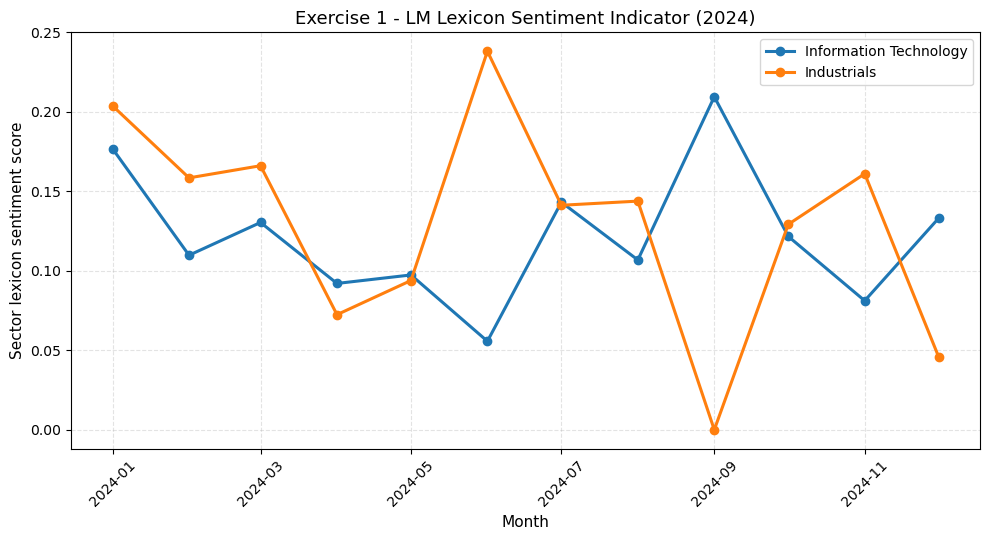

In [30]:
# plot lexicon indicator

plot_sector_indicator(
    df=sector_month_lex,
    score_col="sector_lexicon_score",
    title="Exercise 1 - LM Lexicon Sentiment Indicator (2024)",
    ylabel="Sector lexicon sentiment score",
    save_path=PROCESSED_DIR / "ex1_lexicon_indicator_2024.png",
)

## 12. Plot the FinBERT sentiment indicator
Plot the sector-month sentiment indicator based on the FinBERT method.

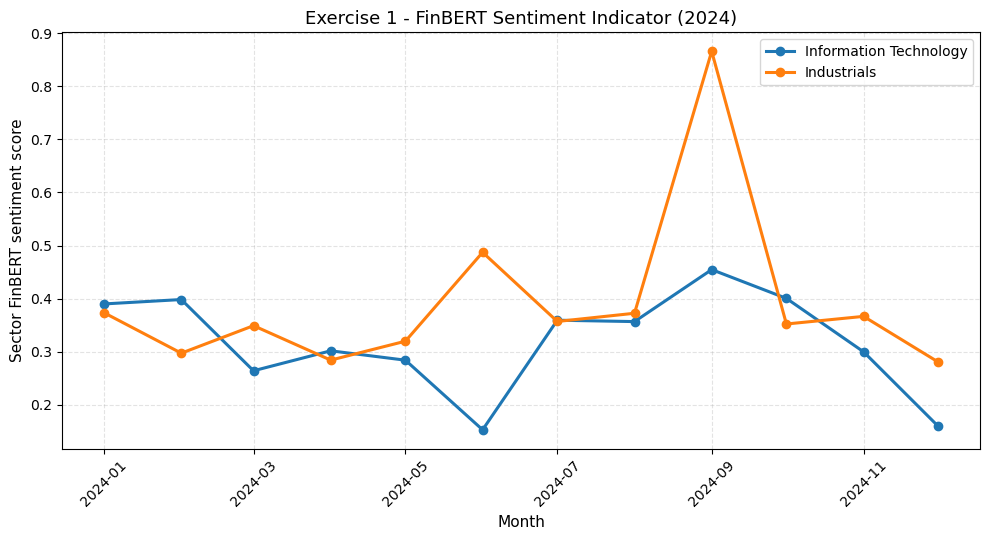

In [31]:
# plot FinBERT indicator

plot_sector_indicator(
    df=sector_month_finbert,
    score_col="sector_finbert_score",
    title="Exercise 1 - FinBERT Sentiment Indicator (2024)",
    ylabel="Sector FinBERT sentiment score",
    save_path=PROCESSED_DIR / "ex1_finbert_indicator_2024.png",
)

## 13. Compare sector-month outputs across methods
Merge the lexicon and FinBERT sector-month tables into a single comparison table.

In [25]:
# merge lexicon and FinBERT monthly indicators

sector_month_compare = sector_month_lex.merge(
    sector_month_finbert,
    on=["sector", "month"],
    how="inner",
    suffixes=("_lexicon", "_finbert"),
)

print(sector_month_compare.shape)
sector_month_compare.sort_values(["month", "sector"]).head(30)

(24, 8)


,sector,month,sector_lexicon_score,n_calls_lexicon,n_firms_lexicon,sector_finbert_score,n_calls_finbert,n_firms_finbert
0,Industrials,2024-01,0.203846,3,3,0.373103,3,3
12,Information Technology,2024-01,0.176838,12,12,0.389788,12,12
1,Industrials,2024-02,0.158523,8,8,0.296912,8,8
13,Information Technology,2024-02,0.109842,18,18,0.398070,18,18
2,Industrials,2024-03,0.166171,2,2,0.348778,2,2
14,Information Technology,2024-03,0.130456,6,6,0.263693,6,6
3,Industrials,2024-04,0.072449,48,48,0.283791,48,48
15,Information Technology,2024-04,0.092097,26,26,0.301368,26,26
4,Industrials,2024-05,0.093937,25,25,0.319488,25,25
16,Information Technology,2024-05,0.097433,25,25,0.283675,25,25


In [26]:
# save comparison table

sector_month_compare_path = PROCESSED_DIR / "ex1_sector_month_method_comparison_2024.parquet"
sector_month_compare.to_parquet(sector_month_compare_path, index=False)

print("Saved comparison table to:", sector_month_compare_path)

Saved comparison table to: D:\Desk\F550_final_peoject\data\processed\ex1_sector_month_method_comparison_2024.parquet


## 14. Plot monthly transcript coverage by sector
Plot the number of company calls contributing to the sector-level sentiment indicator in each month.
This helps interpret whether unusually high or low sentiment values may be driven by limited sample coverage.

In [32]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_monthly_call_coverage(
    df: pd.DataFrame,
    month_col: str = "month",
    sector_col: str = "sector",
    calls_col: str = "n_calls_lexicon",
    title: str = "Exercise 1 - Monthly Transcript Coverage by Sector (2024)",
    ylabel: str = "Number of calls",
    save_path=None,
):
    """
    Plot the number of calls contributing to the monthly sector indicator.

    Parameters
    ----------
    df : pd.DataFrame
        Sector-month comparison DataFrame.
    month_col : str
        Column containing month values.
    sector_col : str
        Column containing sector names.
    calls_col : str
        Column containing monthly call counts.
    title : str
        Figure title.
    ylabel : str
        Y-axis label.
    save_path : str or Path, optional
        If provided, save the figure to this path.
    """
    plot_df = df.copy()
    plot_df[month_col] = pd.to_datetime(plot_df[month_col])

    tech = plot_df.loc[plot_df[sector_col] == "Information Technology"].sort_values(month_col)
    ind = plot_df.loc[plot_df[sector_col] == "Industrials"].sort_values(month_col)

    plt.figure(figsize=(10, 5.5))

    plt.plot(
        tech[month_col],
        tech[calls_col],
        marker="o",
        linewidth=2.2,
        markersize=6,
        label="Information Technology",
    )
    plt.plot(
        ind[month_col],
        ind[calls_col],
        marker="o",
        linewidth=2.2,
        markersize=6,
        label="Industrials",
    )

    plt.title(title, fontsize=13)
    plt.xlabel("Month", fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend(frameon=True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

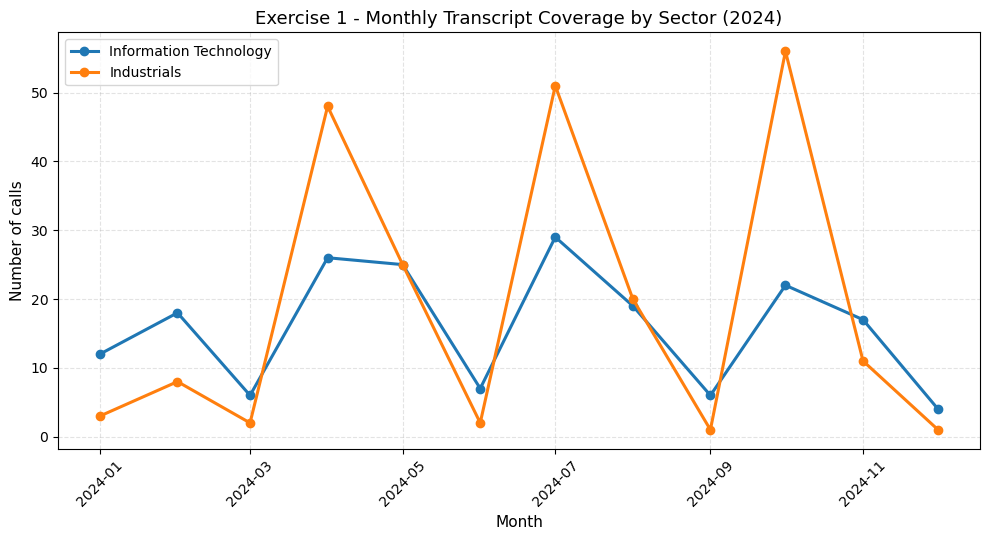

In [33]:
plot_monthly_call_coverage(
    df=sector_month_compare,
    month_col="month",
    sector_col="sector",
    calls_col="n_calls_lexicon",
    title="Exercise 1 - Monthly Transcript Coverage by Sector (2024)",
    ylabel="Number of calls",
    save_path=PROCESSED_DIR / "ex1_monthly_call_coverage_2024.png",
)